# COURSEWORK 2
## Using Machine Learning to Predict Student Academic Performance Based on Hours of Study

**GROUP:** 9

**Members:** 
1. OKUYA DAIRUS LINUS --VU-BAD-2607-4743-DAY
2. AMUKO BRENDA       --VU-BAD-2607-3383-DAY
3. NAMUTEBI LETICIA   --VU-BAD-2603-0146-DAY
4. SSALI RONIE        --VU-BAD-2607-4467-DAY
5. KATANAKA EMMANUEL JULIUS --VU-BAD-2607-1008-DAY 





### Abstract
This project investigates whether the number of hours a student studies per day can be used to predict academic performance. Questionnaire style student data are processed using Python and pandas, cleaned and prepared for modelling, and then used to develop a linear regression model. Model performance is evaluated using MAE, RMSE and R², and the result is compared with a simple mean score baseline.


## 1. Problem Definition and Data Collection

### Domain
**EDUCATION**

### Problem
Students spend different amounts of time studying outside class and their academic results also vary. So this project examines whether study hours can provide useful information for predicting academic performance.

### Research Question
Can a machine learning model predict a student's academic performance based on the number of hours they study per day?

### Objective
To build and evaluate a regression model that predicts a student's academic score from their average daily study hours.

### Hypothesis
   1. Study hours per day do not provide useful predictive information about academic score.*
   2. Study hours per day provide useful predictive information about academic score.*

### Data Collection Instrument
A structured questionnaire was designed using Google Forms to collect information about students' study habits and recent academic performance. The main modelling variables were study_hours_per_day as the predictor and academic_score as the target.


### Evidence of Collection
- **Method:** A Google Forms questionnaire was used to collect the data. A total of 32 responses were received. The following screenshots provide evidence of the questionnaire and the collected responses.
  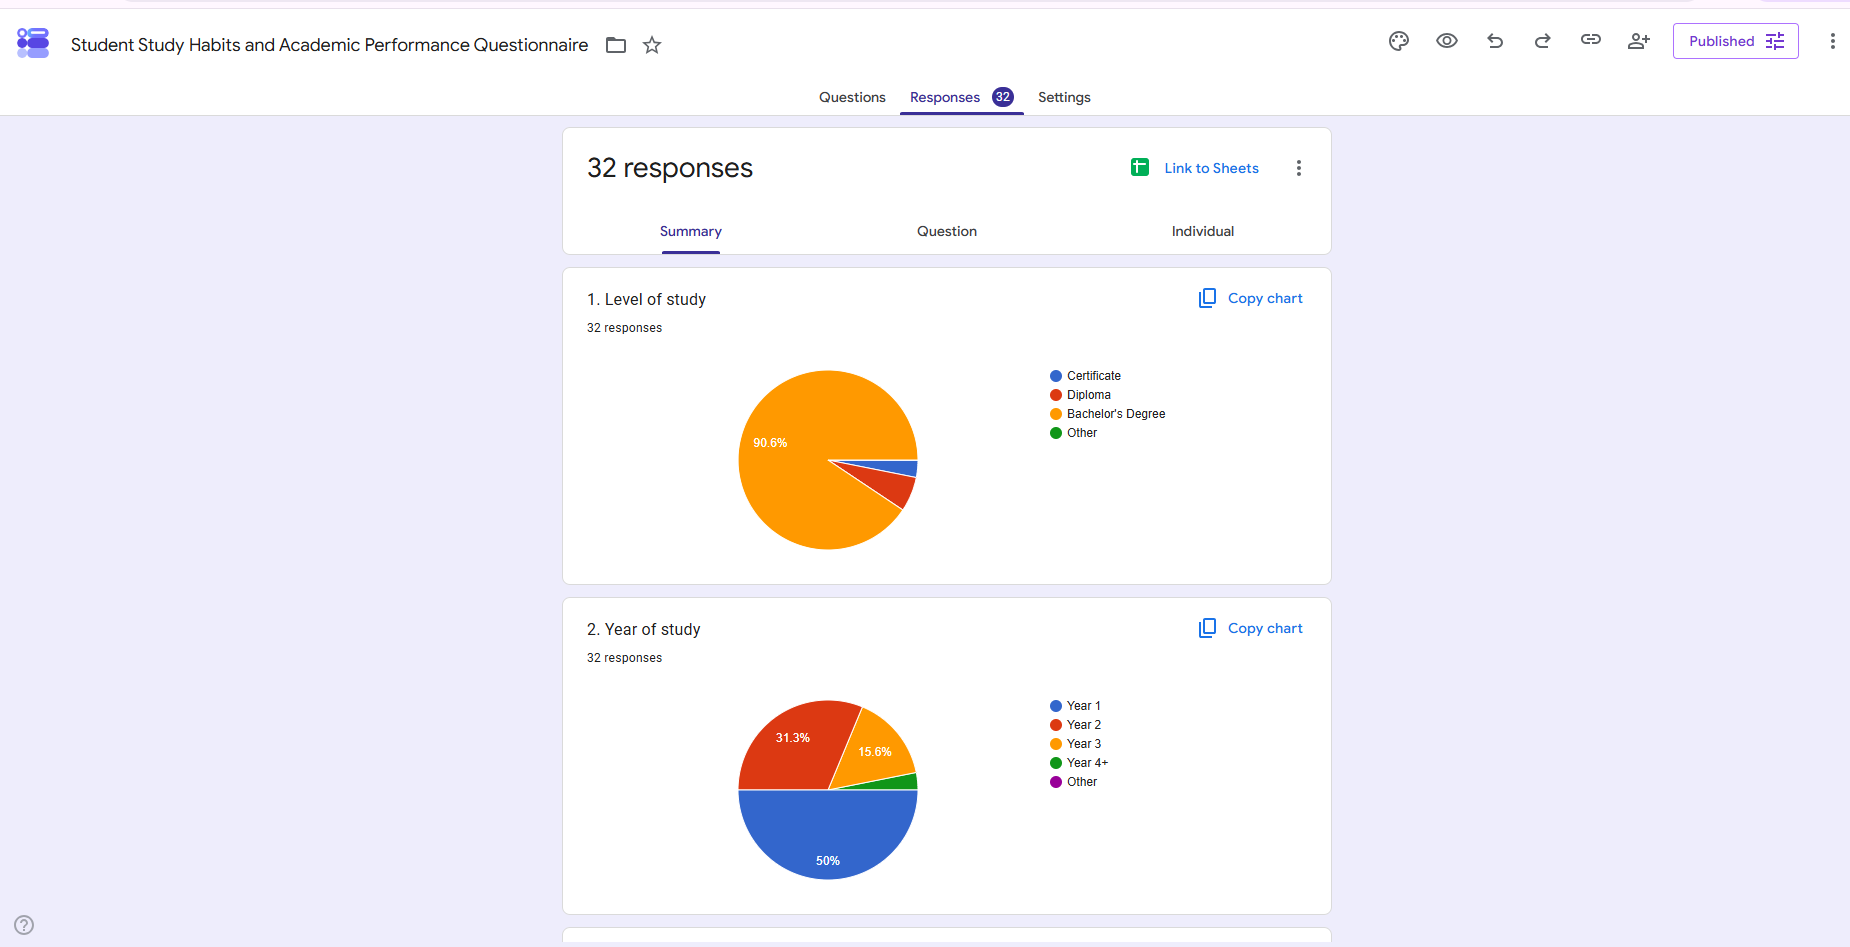Google Forms response summary showing 32 responses.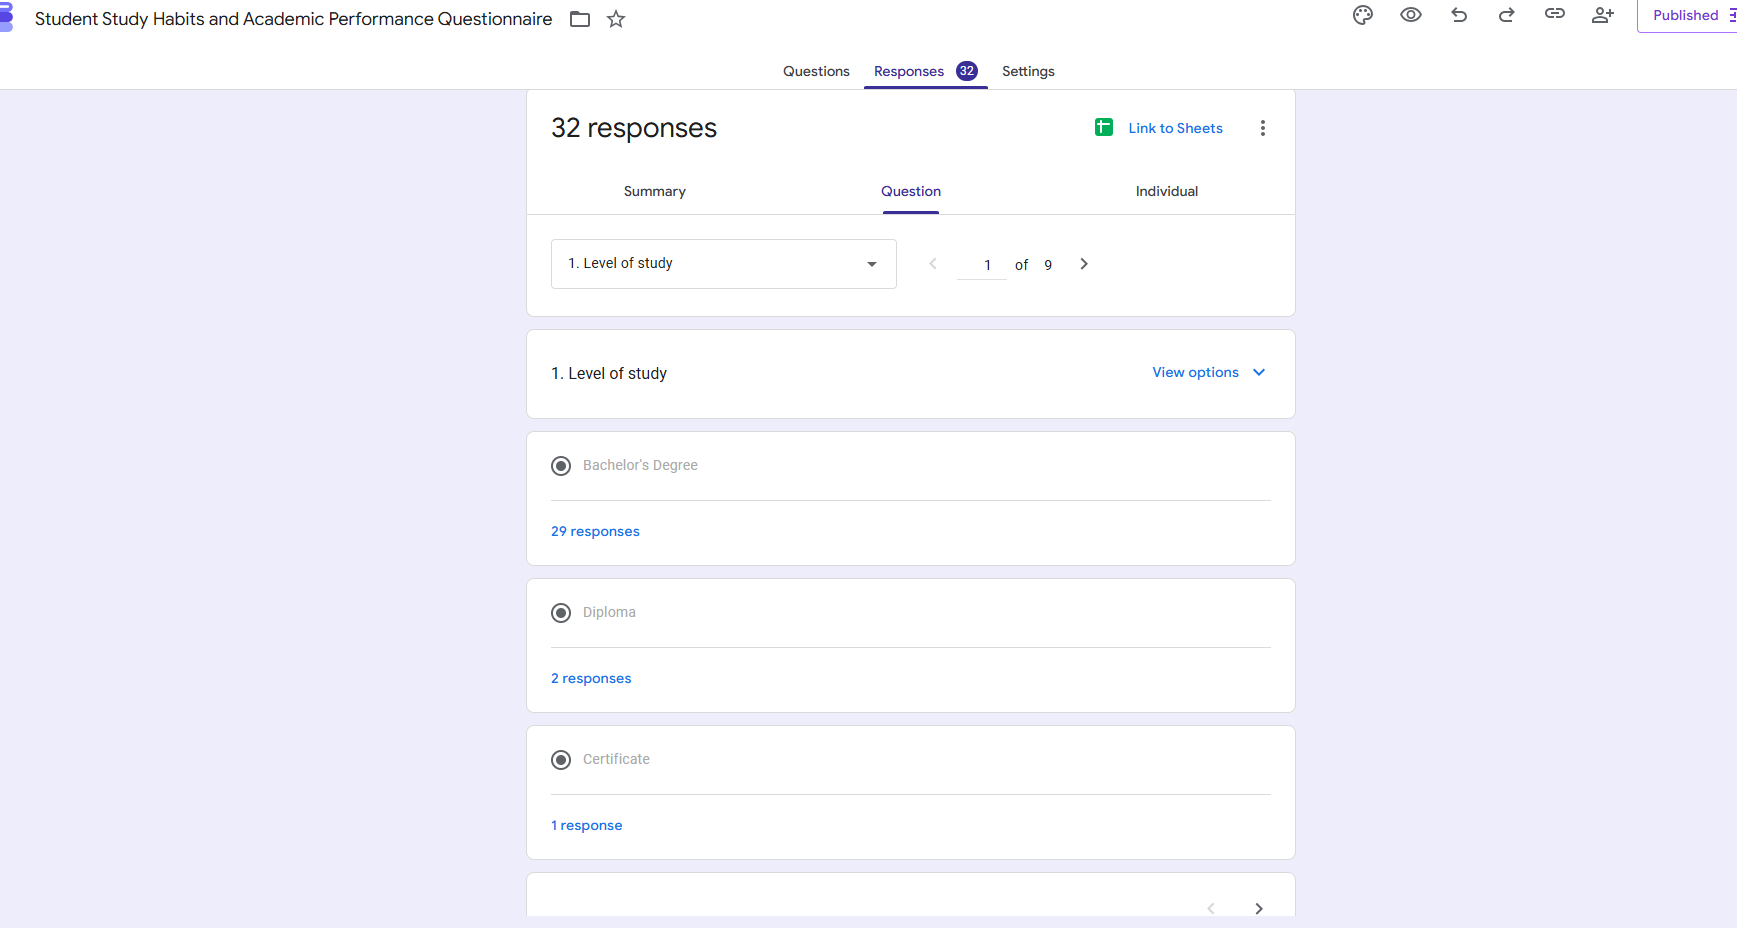Google Forms questionnaire used for data collection.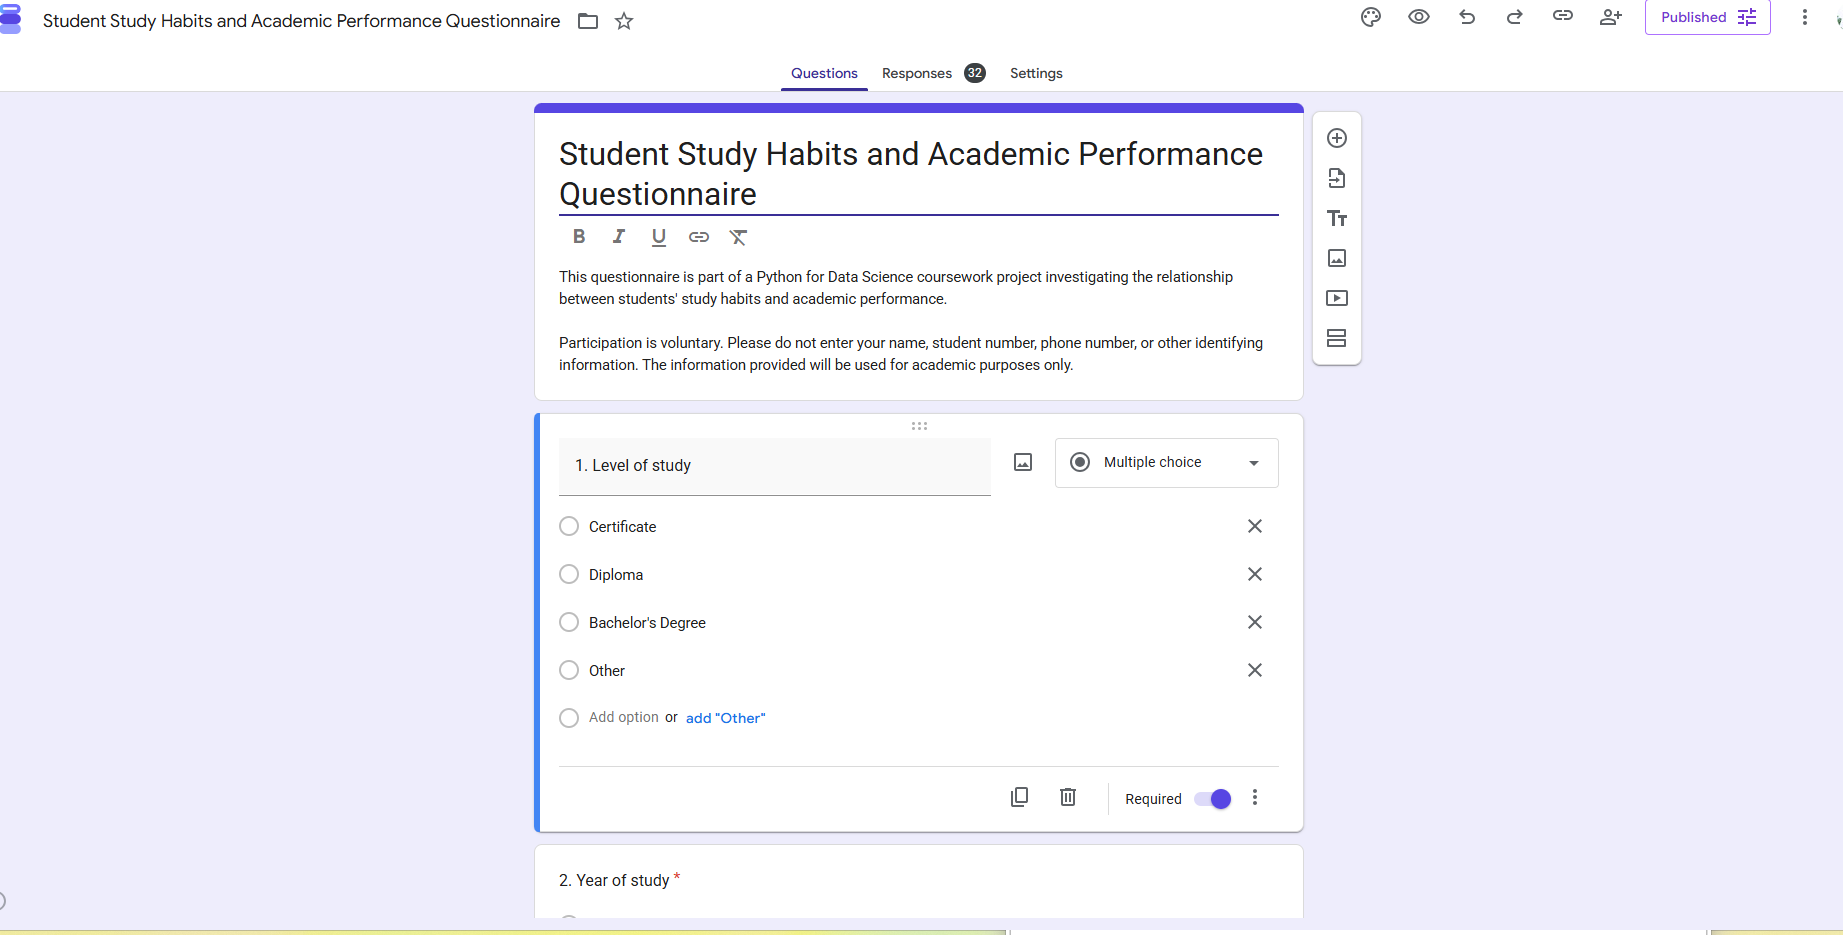
- **Collection log:** The data was collected on 6 October, 2026 using a Google Forms questionnaire. The questionnaire targeted students and was distributed through WhatsApp. A total of 32 responses were received. No major difficulties were encountered during the data collection process.
- **Raw data:** The unmodified CSV export from Google Forms is retained as the raw dataset. The original timestamps and responses are preserved before preprocessing.

### Questionnaire Structure

1. Level of study  
2. Year of study  
3. Average hours studying outside class per day  
4. Number of study days per week  
5. Total study hours per week  
6. Overall percentage in the most recent completed assessment  
7. Score category  
8. Consistency of study schedule  
9. Whether planned study sessions are completed

The questionnaire was designed to avoid collecting names or other unnecessary identifying information.


## 2. Data Loading and Initial Inspection


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

pd.set_option("display.max_columns", None)

# This is the original Google Forms CSV export.
file_path = "Student Study Habits and Academic Performance Questionnaire.csv"
raw_df = pd.read_csv(file_path)

# Rename long Google Forms question labels to short, readable column names.
column_mapping = {
    "Timestamp": "timestamp",
    "1. Level of study": "level_of_study",
    "2. Year of study": "year_of_study",
    "3. On average, how many hours do you study outside class per day?": "study_hours_per_day",
    "4. How many days per week do you normally study outside class?": "study_days_per_week",
    "5. Approximately how many hours do you study outside class in a typical week?": "study_hours_per_week",
    "6. What was your overall percentage in your most recent completed examination or assessment?": "academic_score",
    "7. Which category best describes your most recent academic score?": "score_category",
    "8. How consistent is your study schedule?": "study_consistency",
    "9. Do you normally complete the study sessions you plan?": "completes_study_sessions",
}
df = raw_df.rename(columns=column_mapping).copy()

print("Actual Google Forms responses loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Raw export preserved in raw_df.")


Actual Google Forms responses loaded successfully.
Rows: 32
Columns: 10
Raw export preserved in raw_df.


In [2]:
# First five records
df.head()


,timestamp,level_of_study,year_of_study,study_hours_per_day,study_days_per_week,study_hours_per_week,academic_score,score_category,study_consistency,completes_study_sessions
0,2026/10/06 8:20:30 AM GMT+3,Bachelor's Degree,Year 1,2.0,3,7.0,60,60–69%,Sometimes consistent,Yes
1,2026/10/06 8:25:03 AM GMT+3,Diploma,Year 1,5.0,5,8.0,70,70–79%,Often consistent,Yes
2,2026/10/06 8:26:40 AM GMT+3,Certificate,Year 2,5.0,6,8.0,65,60–69%,Always consistent,Yes
3,2026/10/06 8:28:31 AM GMT+3,Bachelor's Degree,Year 3,3.0,3,6.0,80,80–100%,Often consistent,Sometimes
4,2026/10/06 8:43:07 AM GMT+3,Diploma,Year 2,2.0,6,12.0,89,80–100%,Always consistent,Yes


In [3]:
# Dataset dimensions
print("Dimensions:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nData information:")
df.info()


Dimensions: (32, 10)

Columns:
['timestamp', 'level_of_study', 'year_of_study', 'study_hours_per_day', 'study_days_per_week', 'study_hours_per_week', 'academic_score', 'score_category', 'study_consistency', 'completes_study_sessions']

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 32 non-null     str    
 1   level_of_study            32 non-null     str    
 2   year_of_study             32 non-null     str    
 3   study_hours_per_day       32 non-null     float64
 4   study_days_per_week       32 non-null     int64  
 5   study_hours_per_week      32 non-null     float64
 6   academic_score            32 non-null     int64  
 7   score_category            32 non-null     str    
 8   study_consistency         32 non-null     str    
 9   completes_study_sessions  32 non-null     st

## 3. Data Quality Profile

In [4]:
# Missing values
missing_values = df.isnull().sum()
missing_values


timestamp                   0
level_of_study              0
year_of_study               0
study_hours_per_day         0
study_days_per_week         0
study_hours_per_week        0
academic_score              0
score_category              0
study_consistency           0
completes_study_sessions    0
dtype: int64

In [5]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 0


In [6]:
# Number of unique values in each column
unique_values = df.nunique()
unique_values


timestamp                   32
level_of_study               3
year_of_study                4
study_hours_per_day          8
study_days_per_week          5
study_hours_per_week        18
academic_score              27
score_category               5
study_consistency            5
completes_study_sessions     3
dtype: int64

In [7]:
# Descriptive statistics for numerical variables
df.describe()


,study_hours_per_day,study_days_per_week,study_hours_per_week,academic_score
count,32.000000,32.000000,32.000000,32.000000
mean,2.812500,3.968750,10.906250,84.718750
std,1.209839,1.230903,7.239495,104.715662
min,1.000000,2.000000,2.000000,45.000000
25%,2.000000,3.000000,6.000000,60.000000
50%,2.500000,4.000000,8.500000,65.500000
75%,3.625000,5.000000,14.250000,76.250000
max,5.000000,6.000000,30.000000,655.000000


In [8]:
# Frequency distributions for important categorical variables
print("Level of study:")
print(df["level_of_study"].value_counts())

print("\nYear of study:")
print(df["year_of_study"].value_counts())

print("\nStudy consistency:")
print(df["study_consistency"].value_counts())

print("\nScore category:")
print(df["score_category"].value_counts())


Level of study:
level_of_study
Bachelor's Degree    29
Diploma               2
Certificate           1
Name: count, dtype: int64

Year of study:
year_of_study
Year 1     16
Year 2     10
Year 3      5
Year 4+     1
Name: count, dtype: int64

Study consistency:
study_consistency
Sometimes consistent    12
Often consistent         8
Rarely consistent        6
Always consistent        5
Never consistent         1
Name: count, dtype: int64

Score category:
score_category
60–69%       13
70–79%        8
80–100%       4
50–59%        4
Below 50%     3
Name: count, dtype: int64


## 4. Data Cleaning and Preprocessing
One academic score entry was outside the valid 0–100 percentage range (655); it was treated as invalid for modelling rather than silently corrected. After preprocessing, 31 valid records were used for the regression analysis.

The following preprocessing operations are applied before modelling:
1. A separate working copy is created.
2. Numeric fields are converted to numeric types.
3. Duplicate observations are removed.
4. Rows missing the predictor or target are removed.
5. Impossible study hour and score values are excluded.
6. The prepared dataset is saved separately from the raw dataset.


In [27]:
clean_df = df.copy()

# Convert the modelling variables to numeric. Invalid text becomes missing.
clean_df["study_hours_per_day"] = pd.to_numeric(
    clean_df["study_hours_per_day"], errors="coerce"
)
clean_df["academic_score"] = pd.to_numeric(
    clean_df["academic_score"], errors="coerce"
)

# Remove exact duplicate records, if any.
clean_df = clean_df.drop_duplicates().copy()

# A percentage score must be between 0 and 100.
# Keep the raw value (655) in raw_df/df, but do not use it as a valid score.
invalid_score_mask = ~clean_df["academic_score"].between(0, 100)
print("Records with an invalid academic score:")
display(clean_df.loc[invalid_score_mask, [
    "timestamp", "study_hours_per_day", "academic_score", "score_category"
]])

clean_df.loc[invalid_score_mask, "academic_score"] = np.nan

# Remove records without a valid predictor or target.
clean_df = clean_df.dropna(
    subset=["study_hours_per_day", "academic_score"]
).copy()

# Study hours per day should be between 0 and 24.
clean_df = clean_df[
    clean_df["study_hours_per_day"].between(0, 24)
].copy()

clean_df.reset_index(drop=True, inplace=True)

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(clean_df))
print("Rows removed from modelling:", len(df) - len(clean_df))
print("Note: the original raw export has not been modified.")


Records with an invalid academic score:


,timestamp,study_hours_per_day,academic_score,score_category
13,2026/10/06 8:52:20 AM GMT+3,2.0,655,60–69%


Rows before cleaning: 32
Rows after cleaning: 31
Rows removed from modelling: 1
Note: the original raw export has not been modified.


In [10]:
# Before/after data-quality check
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicates after cleaning:", clean_df.duplicated().sum())


Missing values after cleaning:
timestamp                   0
level_of_study              0
year_of_study               0
study_hours_per_day         0
study_days_per_week         0
study_hours_per_week        0
academic_score              0
score_category              0
study_consistency           0
completes_study_sessions    0
dtype: int64

Duplicates after cleaning: 0


In [11]:
prepared_file = "prepared_student_performance_data.csv"
clean_df.to_csv(prepared_file, index=False)

print("Prepared dataset saved as:", prepared_file)


Prepared dataset saved as: prepared_student_performance_data.csv


## 5. Exploratory Analysis
Exploratory data analysis was performed on the prepared dataset to understand the distribution of the variables and examine the relationship between study hours and academic performance.

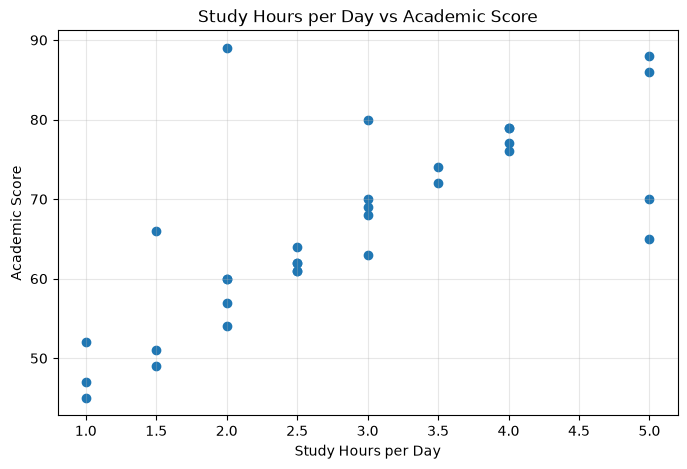

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["study_hours_per_day"], clean_df["academic_score"])
plt.xlabel("Study Hours per Day")
plt.ylabel("Academic Score")
plt.title("Study Hours per Day vs Academic Score")
plt.grid(True, alpha=0.3)
plt.show()


In [32]:
correlation = clean_df["study_hours_per_day"].corr(clean_df["academic_score"])
print(f"Correlation between study hours and academic score: {correlation:.3f}")


Correlation between study hours and academic score: 0.741


## 6. Machine Learning Model

### Problem Type
This is a supervised regression problem because the target variable, academic score, is a continuous numerical value from 0 to 100.

### Variables
- **Predictor (X):** study_hours_per_day
- **Target (y):** academic_score

### Model
A **Linear Regression** model is used because the project investigates whether academic score changes systematically with study hours.

### Evaluation
The data are divided into training and testing sets. Performance is measured using:
- **MAE:** average absolute prediction error.
- **RMSE:** gives greater weight to larger errors.
- **R²:** proportion of variation in the target explained by the model.

A **Dummy Regressor** predicting the training-set mean is used as a baseline.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = clean_df[["study_hours_per_day"]]
y = clean_df["academic_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 24
Testing observations: 7


### Custom Evaluation Function

In [15]:
def evaluate_regression(model, X_test, y_test):
    """Return common regression evaluation metrics."""
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


In [16]:
# Baseline model
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_metrics = evaluate_regression(
    baseline, X_test, y_test
)

baseline_metrics


{'MAE': 10.696428571428573,
 'RMSE': np.float64(13.31448630758696),
 'R2': -0.11594318295363726}

In [17]:
# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model_metrics = evaluate_regression(
    model, X_test, y_test
)

model_metrics


{'MAE': 4.220642515379355,
 'RMSE': np.float64(5.355687562013254),
 'R2': 0.8194390963729098}

##  Model Comparison

In [18]:
comparison = pd.DataFrame(
    [baseline_metrics, model_metrics],
    index=["Mean Baseline", "Linear Regression"]
)

comparison


,MAE,RMSE,R2
Mean Baseline,10.696429,13.314486,-0.115943
Linear Regression,4.220643,5.355688,0.819439


In [19]:
print("Intercept:", model.intercept_)
print("Study-hours coefficient:", model.coef_[0])

print(
    f"Prediction equation: Academic Score = "
    f"{model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × Study Hours per Day)"
)


Intercept: 49.08197767145136
Study-hours coefficient: 6.199043062200957
Prediction equation: Academic Score = 49.08 + (6.20 × Study Hours per Day)


## Predictions

In [20]:
example_hours = pd.DataFrame({
    "study_hours_per_day": [1, 2, 3, 4, 5, 6]
})

example_predictions = model.predict(example_hours)

prediction_table = example_hours.copy()
prediction_table["predicted_academic_score"] = example_predictions.round(2)

prediction_table


,study_hours_per_day,predicted_academic_score
0,1,55.28
1,2,61.48
2,3,67.68
3,4,73.88
4,5,80.08
5,6,86.28


In [21]:
# Predictions for the held-out test data
test_results = X_test.copy()
test_results["actual_score"] = y_test.values
test_results["predicted_score"] = model.predict(X_test)
test_results["absolute_error"] = (
    test_results["actual_score"] - test_results["predicted_score"]
).abs()

test_results.sort_values("study_hours_per_day")


,study_hours_per_day,actual_score,predicted_score,absolute_error
27,1.0,45.0,55.281021,10.281021
9,1.0,52.0,55.281021,3.281021
8,2.5,64.0,64.579585,0.579585
15,2.5,61.0,64.579585,3.579585
29,2.5,62.0,64.579585,2.579585
17,3.0,69.0,67.679107,1.320893
23,5.0,88.0,80.077193,7.922807


## Model Visualisation

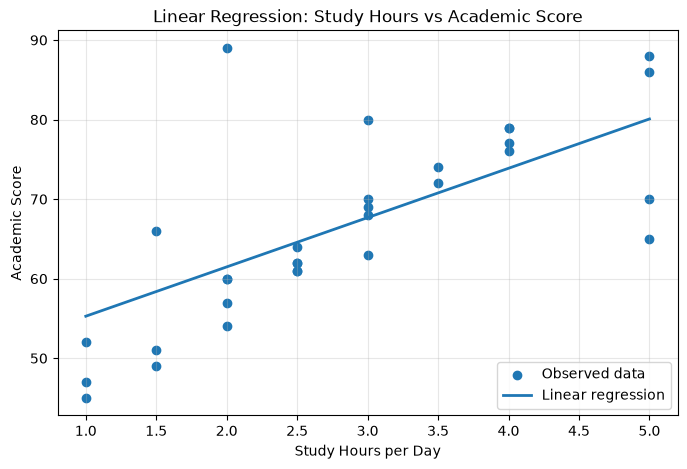

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(
    clean_df["study_hours_per_day"],
    clean_df["academic_score"],
    label="Observed data"
)

x_line = np.linspace(
    clean_df["study_hours_per_day"].min(),
    clean_df["study_hours_per_day"].max(),
    100
)

y_line = model.predict(pd.DataFrame({
    "study_hours_per_day": x_line
}))

plt.plot(x_line, y_line, linewidth=2, label="Linear regression")
plt.xlabel("Study Hours per Day")
plt.ylabel("Academic Score")
plt.title("Linear Regression: Study Hours vs Academic Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


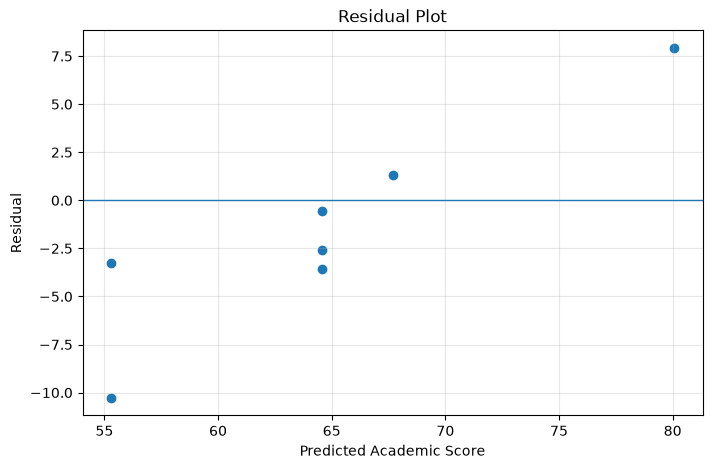

In [23]:
# Residual analysis
test_predictions = model.predict(X_test)
residuals = y_test - test_predictions

plt.figure(figsize=(8, 5))
plt.scatter(test_predictions, residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Academic Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()


## Reproducibility and Error Checking

In [24]:
import sys

print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("scikit-learn version:", sklearn.__version__)

assert X.shape[0] == y.shape[0], "X and y must have the same number of rows."
assert clean_df["study_hours_per_day"].between(0, 24).all()
assert clean_df["academic_score"].between(0, 100).all()

print("Basic validation checks passed.")


Python version: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
pandas version: 3.0.6
NumPy version: 2.5.3
scikit-learn version: 1.9.1
Basic validation checks passed.


##  Algorithm / Process

### Pseudocode
1. Start
2. Load the raw CSV dataset
3. Inspect rows, columns and data types
4. Check missing values and duplicates
5. Convert required variables to numeric types
6. Remove invalid or unusable observations
7. Save the prepared dataset
8. Select study hours as X and academic score as y
9. Split data into training and testing sets
10. Train the mean baseline
11. Train the linear regression model
12. Generate predictions
13. Calculate MAE, RMSE and R²
14. Compare the model with the baseline
15. Visualise the relationship and residuals
16. Interpret the results
17. End


### Process Flow

**Raw questionnaire data → Load with pandas → Inspect → Clean → Validate → Save prepared data → Select X and y → Train/test split → Baseline + Linear Regression → Predictions → Metrics → Visualisations → Interpretation**


##  Results and Discussion

The analysis uses the 32 responses collected through the Google Forms questionnaire. During validation, one response contained an academic score of **655**, which is outside the valid percentage range of 0–100. The raw response is preserved in the original CSV, but this invalid score is excluded from modelling. The model therefore uses **31 valid records**.

Interpret the model using the correlation, regression coefficient, evaluation metrics, and comparison with the mean baseline shown above. A positive study-hours coefficient means the fitted model predicts a higher score for each additional daily study hour in this sample. MAE describes the average absolute prediction error in score points; RMSE gives more weight to larger errors; R² indicates the proportion of test-score variation explained by the model.

Because the sample is small and uses only one predictor, the results should not be generalized to all university students. The model shows an association in this sample, not proof that studying more hours alone causes higher scores. The baseline comparison helps determine whether the regression model performs better than simply predicting the average training score.


##  Limitations

1. Academic performance is influenced by many factors besides study hours, including attendance, prior knowledge, learning environment, teaching quality and assessment difficulty.
2. Using only one main predictor limits the explanatory power of the model.
3. The dataset size is relatively small for a general-purpose predictive system.
4. Linear regression assumes a roughly linear relationship between the predictor and target.
5. The results should not be interpreted as proving that increasing study hours alone causes higher academic performance.


##  Possible Improvements

Future versions could include additional predictors such as attendance, sleep duration, previous academic results, access to learning materials, study environment and class participation. A larger dataset could also be collected and models such as decision trees, random forests or other regression methods could be compared using cross-validation.


## Conclusion

This project demonstrates a Python data-science workflow using actual questionnaire responses collected through Google Forms. The original raw CSV was loaded and preserved, the data were inspected and validated, and an invalid academic-score entry was excluded from modelling because it exceeded the possible percentage range. A linear regression model was trained to predict academic score from average daily study hours and was compared with a mean baseline.

The findings should be interpreted cautiously because the dataset contains only 31 valid modelling records and uses study hours as its only predictor. The model evaluates predictive usefulness within this sample; it does not prove causation or guarantee accurate predictions for other students.
